# 🚗 Notebook 02: Data Cleaning, Feature Engineering & Exploratory Data Analysis (EDA)
> **Project**: Cambodia Used Car Price Prediction  
> **Dataset**: Khmer24 Raw Ingestion Data Lake (`data/raw/*.parquet`) & Processed ML Features  
> **Level**: Intermediate Data Cleaning, Domain Feature Engineering & In-Depth EDA  
> **Pipeline Architecture**: **Medallion Pattern** (Bronze $\rightarrow$ Silver $\rightarrow$ Gold)

---

## 📌 Objectives & Processing Workflow
This notebook demonstrates an intermediate-level end-to-end data cleaning, imputation, feature engineering, and exploratory data analysis pipeline:
1. **Bronze Layer Ingestion & Profiling**: Dynamic multi-partition Parquet loading, missing value profiling, and raw data lake structure audit.
2. **Silver Layer (Deduplication & Sanity Cleaning)**: Time-series snapshot deduplication to latest listing state, historical change feature extraction (`days_on_market`, `price_drop_amount`, `has_price_drop`, `view_velocity`), deterministic sanity filtering rules, and typo/format standardizations.
3. **Gold Layer (Imputation & Domain Feature Engineering)**: Contextual grouped median imputation (model year, mileage with missingness indicator, mode by model for fuel/transmission), domain feature extraction for Cambodia's car market (vehicle age, depreciation squared, brand tiers, location tiers, and equipment option keyword flags), plus target log-transformation $\ln(1 + \text{price})$.
4. **Target Variable & Normality Analysis**: Visual and statistical evaluation of skewness, kurtosis, and variance stabilization.
5. **Univariate Market Distributions**: Analysis of car manufacturing years, brand market shares, tax classifications, condition, and geographic distribution.
6. **Bivariate Valuation Dynamics**: Depreciation curves, brand hierarchy boxplots, tax paper vs plate number pricing premiums, mileage impact, equipment options value, and geographic price tiers.
7. **Correlation & Multicollinearity Matrix**: Heatmap correlations between numerical/binary proxy features and the target variable `log_price`.
8. **Executive Summary**: Core business takeaways and model-ready handoff for supervised learning.


---
## ⚙️ 1. Setup & Environment Initialization
We import standard data science tools: `pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`, `scipy.stats`, and path utilities.


In [1]:
# ── 1. Setup & Imports ────────────────────────────────────────────────────────
import os
import re
import sys
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime

# Visual styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

# Project paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if "notebooks" in os.getcwd() else os.getcwd()
RAW_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DATA_DIR = os.path.join(PROJECT_ROOT, "data", "processed")

print("✅ Setup complete.")
print(f"📁 Project Root       : {PROJECT_ROOT}")
print(f"📁 Raw Data Directory : {RAW_DATA_DIR}")


✅ Setup complete.
📁 Project Root       : d:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction
📁 Raw Data Directory : d:\ITC3_AMS_2025\I4_AMS_S2\Y4_Internship\Car_price_prediction\data\raw


---
## 📦 2. Bronze Layer: Raw Data Lake Ingestion & Missingness Profiling
In a production marketplace pipeline, data arrives as daily partitioned Parquet files (`cars_YYYY-MM-DD.parquet`). We dynamically discover, load, and concatenate all available partitions into a unified Bronze DataFrame, then profile initial feature sparsity.


In [2]:
# ── 2. Load and Concatenate Bronze Raw Partitions ─────────────────────────────
raw_parquet_files = sorted(glob.glob(os.path.join(RAW_DATA_DIR, "cars_*.parquet")))
print(f"🔍 Found {len(raw_parquet_files)} raw Parquet partition(s):")
for f in raw_parquet_files:
    print(f"   • {os.path.basename(f)}")

if raw_parquet_files:
    raw_dfs = [pd.read_parquet(f) for f in raw_parquet_files]
    df_bronze = pd.concat(raw_dfs, ignore_index=True)
else:
    # Fallback to single sample CSV/parquet if no raw partitions are present
    sample_file = os.path.join(RAW_DATA_DIR, "khmer24_cars_sample_60.csv")
    if os.path.exists(sample_file):
        df_bronze = pd.read_csv(sample_file)
    else:
        raise FileNotFoundError(f"No raw data found in {RAW_DATA_DIR}")

print("\n" + "=" * 60)
print(f"📊 Bronze Raw Data Lake Summary:")
print(f"  • Total Snapshot Rows  : {len(df_bronze):,}")
print(f"  • Total Columns        : {len(df_bronze.columns)}")
print(f"  • Unique Listing IDs   : {df_bronze['listing_id'].nunique():,}")
if 'scraped_at' in df_bronze.columns:
    print(f"  • Ingestion Date Range : {df_bronze['scraped_at'].min()[:10]} to {df_bronze['scraped_at'].max()[:10]}")
print("=" * 60)

# Display sample raw records
preview_cols = [c for c in ['listing_id', 'listing_title', 'price', 'vehicle_model_year', 'vehicle_brand', 'vehicle_model', 'province', 'scraped_at'] if c in df_bronze.columns]
display(df_bronze[preview_cols].head(5))


🔍 Found 4 raw Parquet partition(s):
   • cars_2026-08-17.parquet
   • cars_2026-08-18.parquet
   • cars_2026-08-19.parquet
   • cars_2026-08-20.parquet

📊 Bronze Raw Data Lake Summary:
  • Total Snapshot Rows  : 1,925
  • Total Columns        : 34
  • Unique Listing IDs   : 1,559
  • Ingestion Date Range : 2026-08-17 to 2026-08-20


,listing_id,listing_title,price,vehicle_model_year,vehicle_brand,vehicle_model,province,scraped_at
0,13718096,2026 palisade,68800.0,2026,Hyundai,Palisade,Phnom Penh,2026-08-17T08:50:50.130959+00:00
1,13893444,2026 AVATR 07 ELITE FULL OPTION INSTOCK,38500.0,2026,NaN,NaN,Phnom Penh,2026-08-17T08:50:50.130959+00:00
2,13763369,RR Sport 2011 Hse,11800.0,2011,NaN,NaN,Phnom Penh,2026-08-17T08:50:50.140572+00:00
3,13874032,NX300 Fsport ឆ្នាំ2018 (36000$),36000.0,2018,Lexus,NX300,Phnom Penh,2026-08-17T08:50:50.143004+00:00
4,13843539,Kia Kanival 2017​ (ម្ចាស់ដើម) មិនធ្លាប់ខូច,16500.0,2017,Kia,Kanival 2017​ (ម្ចាស់ដើម),Phnom Penh,2026-08-17T08:50:50.143004+00:00


🔍 Top Missing Features in Raw Data Lake:


,Missing Count,Missing Percentage (%),Data Type
vehicle_mileage_km,1925,100.0,object
discount_price,1925,100.0,object
vehicle_engine_cc,1925,100.0,object
vehicle_transmission,1925,100.0,object
vehicle_fuel_type,1925,100.0,object
vehicle_color,1925,100.0,object
is_premium,1925,100.0,object
vehicle_model,682,35.4,str
vehicle_brand,673,35.0,str
thumbnail_url,20,1.0,str


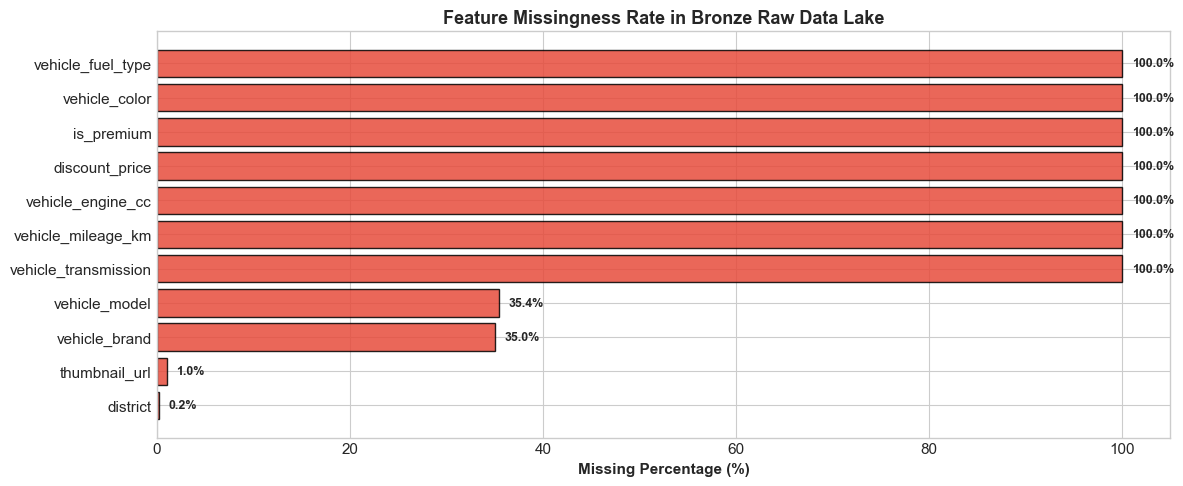

In [3]:
# ── 2.1 Feature Missingness Profiling ──────────────────────────────────────────
missing_counts = df_bronze.isnull().sum()
missing_pcts = (missing_counts / len(df_bronze) * 100).round(1)

df_missing = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pcts,
    'Data Type': df_bronze.dtypes
}).sort_values('Missing Count', ascending=False)

print("🔍 Top Missing Features in Raw Data Lake:")
display(df_missing[df_missing['Missing Count'] > 0].head(12))

# Plot Missingness Bar Chart
plt.figure(figsize=(12, 5))
missing_plot_data = df_missing[df_missing['Missing Percentage (%)'] > 0]['Missing Percentage (%)'].sort_values()
bars = plt.barh(missing_plot_data.index, missing_plot_data.values, color='#e74c3c', edgecolor='black', alpha=0.85)
plt.xlabel('Missing Percentage (%)', fontweight='bold')
plt.title('Feature Missingness Rate in Bronze Raw Data Lake', fontweight='bold', fontsize=13)
plt.xlim(0, 105)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 1, bar.get_y() + bar.get_height()/2, f"{w:.1f}%", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🧼 3. Silver Layer: Multi-Day Deduplication & Sanity Cleaning
Marketplace time-series logs record multiple daily snapshots for the same vehicle as sellers update prices, view counts accumulate, or posts are renewed.

### Cleaning Rules Applied:
1. **Deduplication to Latest State**: Group by `listing_id` and pick the record with the maximum `scraped_at` timestamp:
   $$\text{Latest Snapshot} = \arg\max_{t} (\text{scraped\_at} \mid \text{listing\_id} = i)$$
2. **Historical Feature Signals**: Compute aggregate change signals before discarding older snapshots:
   - `days_on_market` $= (\max(\text{scraped\_at}) - \min(\text{posted\_at})).\text{days}$
   - `price_drop_amount` $= \text{initial\_price} - \text{latest\_price}$ (clipped at $\ge 0$)
   - `has_price_drop` $= 1$ if price was lowered, else $0$
   - `view_velocity` $= \text{view\_count} / \max(\text{days\_on\_market}, 1)$
3. **Price Sanity Bounds**: Retain listings where $\$500 \le \text{price} \le \$300,000$ (filters accessory deposits and extreme outliers).
4. **Model Year Sanity**: Retain $1990 \le \text{vehicle\_model\_year} \le 2027$.
5. **Mileage & Engine Sanity**: Filter $0 \le \text{mileage\_km} \le 500,000$ and $500 \le \text{engine\_cc} \le 7000$ (treating $0\text{ km}$ on older used cars as `NaN`).
6. **String & Typo Standardizations**: Normalize whitespace and canonical representations.


In [4]:
# ── 3.1 Multi-Day Deduplication & Historical Change Extraction ────────────────
df_silver_raw = df_bronze.copy()

# Parse datetime timestamps
df_silver_raw['scraped_at_dt'] = pd.to_datetime(df_silver_raw['scraped_at'], errors='coerce', utc=True)
df_silver_raw['posted_at_dt'] = pd.to_datetime(df_silver_raw['posted_at'], errors='coerce', utc=True)

# 1. Extract historical change aggregates across snapshots per listing_id
hist_stats = df_silver_raw.groupby('listing_id').agg(
    first_scraped=('scraped_at_dt', 'min'),
    last_scraped=('scraped_at_dt', 'max'),
    first_price=('price', 'first'),
    last_price=('price', 'last'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    snapshot_count=('scraped_at', 'count')
).reset_index()

hist_stats['price_drop_amount'] = (hist_stats['first_price'] - hist_stats['last_price']).clip(lower=0)
hist_stats['has_price_drop'] = (hist_stats['price_drop_amount'] > 0).astype(int)

# 2. Sort chronologically and take the most recent snapshot per listing_id
df_silver_sorted = df_silver_raw.sort_values('scraped_at_dt', ascending=True)
df_silver = df_silver_sorted.drop_duplicates(subset=['listing_id'], keep='last').copy()

# 3. Merge historical change signals back
df_silver = df_silver.merge(
    hist_stats[['listing_id', 'price_drop_amount', 'has_price_drop', 'snapshot_count']],
    on='listing_id',
    how='left'
)

# 4. Compute Days on Market and View Velocity
df_silver['days_on_market'] = (df_silver['scraped_at_dt'] - df_silver['posted_at_dt']).dt.total_seconds() / 86400.0
df_silver['days_on_market'] = df_silver['days_on_market'].clip(lower=0).fillna(1.0)
df_silver['view_velocity'] = df_silver['view_count'] / df_silver['days_on_market'].clip(lower=1.0)

print(f"✅ Deduplication complete: {len(df_bronze):,} raw rows ➔ {len(df_silver):,} unique physical listings.")


✅ Deduplication complete: 1,925 raw rows ➔ 1,559 unique physical listings.


In [5]:
# ── 3.2 Sanity Filtering Rules ─────────────────────────────────────────────────
initial_silver_count = len(df_silver)

# Rule 1 & 2: Valid Price Filter ($500 to $300,000 USD)
df_filtered = df_silver[
    df_silver['price'].notna() &
    (df_silver['price'] >= 500) &
    (df_silver['price'] <= 300000)
].copy()
dropped_price = initial_silver_count - len(df_filtered)

# Rule 3: Valid Year Bounds (1990 <= year <= 2027)
df_filtered = df_filtered[
    (df_filtered['vehicle_model_year'].isna()) |
    ((df_filtered['vehicle_model_year'] >= 1990) & (df_filtered['vehicle_model_year'] <= 2027))
].copy()

# Rule 4: Clean Mileage (0 to 500,000 km, zero-mileage correction on older cars)
def sanitize_mileage(row):
    m = row.get('vehicle_mileage_km')
    if pd.isna(m):
        return np.nan
    try:
        val = float(m)
    except (ValueError, TypeError):
        return np.nan
    if val < 0 or val > 500000:
        return np.nan
    year = row.get('vehicle_model_year')
    cond = str(row.get('vehicle_condition', '')).lower()
    # If mileage is 0 km for a used car older than 3 years, treat as missing rather than true 0
    if val == 0 and cond == 'used' and pd.notna(year) and (2026 - int(year) > 3):
        return np.nan
    return val

df_filtered['vehicle_mileage_km'] = df_filtered.apply(sanitize_mileage, axis=1)

# Rule 5: Engine CC Bounds (500 <= cc <= 7000)
def sanitize_engine_cc(val):
    if pd.isna(val):
        return np.nan
    try:
        cc = float(val)
        return cc if 500 <= cc <= 7000 else np.nan
    except (ValueError, TypeError):
        return np.nan

df_filtered['vehicle_engine_cc'] = df_filtered['vehicle_engine_cc'].apply(sanitize_engine_cc)

# Rule 6: String Standardizations
str_cols = ['vehicle_brand', 'vehicle_model', 'vehicle_condition', 'vehicle_tax_type', 'vehicle_fuel_type', 'vehicle_transmission', 'province', 'seller_type']
for col in str_cols:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].astype(str).str.strip()
        df_filtered[col] = df_filtered[col].replace(['None', 'nan', '', 'Unknown'], np.nan)

print("=" * 60)
print(f"🧹 Silver Layer Cleaning Summary:")
print(f"  • Deduplicated Input Listings : {initial_silver_count:,}")
print(f"  • Cleaned Output Listings     : {len(df_filtered):,}")
print(f"  • Retention Rate              : {len(df_filtered) / initial_silver_count * 100:.2f}%")
print(f"  • Dropped Invalid/Outliers    : {initial_silver_count - len(df_filtered):,}")
print("=" * 60)


🧹 Silver Layer Cleaning Summary:
  • Deduplicated Input Listings : 1,559
  • Cleaned Output Listings     : 1,555
  • Retention Rate              : 99.74%
  • Dropped Invalid/Outliers    : 4


---
## 🏆 4. Gold Layer: Missing Value Imputation & Domain Feature Engineering
In the Gold layer, we transform cleaned listings into a rich, model-ready feature matrix tailored for regression algorithms.

### 1. Imputation Strategy
- **`vehicle_model_year`**: Grouped median by `(vehicle_brand, vehicle_model)` $\rightarrow$ Grouped median by `vehicle_brand` $\rightarrow$ Overall median.
- **`vehicle_mileage_km`**: Grouped median by `(vehicle_model_year, vehicle_brand)` with an added boolean flag `is_mileage_imputed` to retain missingness information.
- **`vehicle_condition`**: Default to `'used'` (>95% of marketplace listings).
- **`vehicle_fuel_type` & `vehicle_transmission`**: Mode by vehicle model (e.g., Prius $\rightarrow$ Hybrid, Automatic).
- **`province`**: Default to `'Phnom Penh'` (the primary commercial hub).

### 2. Domain Feature Engineering (Cambodia Car Market)
- **`vehicle_age`**: $\text{Current Year} - \text{vehicle\_model\_year}$
- **`vehicle_age_squared`**: $(\text{vehicle\_age})^2$ (captures exponential initial depreciation).
- **`mileage_per_year`**: $\frac{\text{vehicle\_mileage\_km}}{\text{vehicle\_age} + 1}$ (measures usage intensity).
- **Brand Tiers**:
  - `is_popular_brand`: Toyota, Lexus, Ford, Hyundai, Kia, Mazda (high market liquidity).
  - `is_luxury_brand`: Lexus, Mercedes-Benz, BMW, Porsche, Land Rover, Audi, Cadillac.
  - `is_chinese_ev_brand`: BYD, Denza, MG, Geely, Haval, GAC, Jetour, Changan, Zeekr, Li Auto.
- **Location Tiers**:
  - `Tier 1`: Phnom Penh (highest liquidity and transaction volume).
  - `Tier 2`: Siem Reap, Battambang, Kandal, Preah Sihanouk, Kampong Cham.
  - `Tier 3`: Secondary/Rural provinces.
- **Equipment & Listing Option Flags (NLP Regex)**:
  - `has_full_option`, `has_sunroof_solar`, `has_leather_seats`, `is_urgent_sale`.
- **Target Variable**: $\text{log\_price} = \ln(1 + \text{price})$ to stabilize variance and normalize right-skewness.


In [6]:
# ── 4.1 Missing Value Imputation ──────────────────────────────────────────────
df_gold = df_filtered.copy()

# 1. Year Imputation (Grouped medians)
overall_median_year = df_gold['vehicle_model_year'].median()
year_by_bm = df_gold.groupby(['vehicle_brand', 'vehicle_model'])['vehicle_model_year'].transform('median')
year_by_b = df_gold.groupby('vehicle_brand')['vehicle_model_year'].transform('median')
df_gold['vehicle_model_year'] = df_gold['vehicle_model_year'].fillna(year_by_bm).fillna(year_by_b).fillna(overall_median_year).astype(int)

# 2. Mileage Imputation (Grouped medians + Missing Indicator)
df_gold['is_mileage_imputed'] = df_gold['vehicle_mileage_km'].isna().astype(int)
mileage_by_yb = df_gold.groupby(['vehicle_model_year', 'vehicle_brand'])['vehicle_mileage_km'].transform('median')
mileage_by_y = df_gold.groupby('vehicle_model_year')['vehicle_mileage_km'].transform('median')
overall_median_mileage = df_gold['vehicle_mileage_km'].median() if df_gold['vehicle_mileage_km'].notna().any() else 80000.0
df_gold['vehicle_mileage_km'] = df_gold['vehicle_mileage_km'].fillna(mileage_by_yb).fillna(mileage_by_y).fillna(overall_median_mileage).fillna(80000.0)

# 3. Categoricals Imputation
df_gold['vehicle_condition'] = df_gold['vehicle_condition'].fillna('used')
df_gold['province'] = df_gold['province'].fillna('Phnom Penh')
df_gold['vehicle_tax_type'] = df_gold['vehicle_tax_type'].fillna('Tax Paper')
df_gold['vehicle_fuel_type'] = df_gold['vehicle_fuel_type'].fillna('Petrol')
df_gold['vehicle_transmission'] = df_gold['vehicle_transmission'].fillna('Automatic')
df_gold['vehicle_brand'] = df_gold['vehicle_brand'].fillna('Unknown')
df_gold['vehicle_model'] = df_gold['vehicle_model'].fillna('Other')
df_gold['seller_type'] = df_gold['seller_type'].fillna('individual')

print("✅ Missing value imputation complete. Remaining nulls in core features:")
print(df_gold[['price', 'vehicle_model_year', 'vehicle_mileage_km', 'vehicle_brand', 'province']].isnull().sum())


✅ Missing value imputation complete. Remaining nulls in core features:
price                 0
vehicle_model_year    0
vehicle_mileage_km    0
vehicle_brand         0
province              0
dtype: int64


In [7]:
# ── 4.2 Domain-Specific Feature Engineering ───────────────────────────────────
CURRENT_YEAR = 2026

# 1. Temporal & Depreciation Features
df_gold['vehicle_age'] = (CURRENT_YEAR - df_gold['vehicle_model_year']).clip(lower=0)
df_gold['vehicle_age_squared'] = df_gold['vehicle_age'] ** 2
df_gold['mileage_per_year'] = df_gold['vehicle_mileage_km'] / (df_gold['vehicle_age'] + 1.0)

# 2. Target Variable Transformation
df_gold['log_price'] = np.log1p(df_gold['price'])

# 3. Market Brand Tiers
POPULAR_BRANDS = {'Toyota', 'Lexus', 'Ford', 'Hyundai', 'Kia', 'Mazda'}
LUXURY_BRANDS = {'Lexus', 'Mercedes-Benz', 'BMW', 'Porsche', 'Land Rover', 'Audi', 'Cadillac', 'Rolls-Royce', 'Bentley'}
CHINESE_EV_BRANDS = {'BYD', 'Denza', 'MG', 'Geely', 'Haval', 'GAC', 'Jetour', 'Changan', 'Zeekr', 'Li Auto', 'Fangchengbao', 'iCar'}

df_gold['is_popular_brand'] = df_gold['vehicle_brand'].isin(POPULAR_BRANDS).astype(int)
df_gold['is_luxury_brand'] = df_gold['vehicle_brand'].isin(LUXURY_BRANDS).astype(int)
df_gold['is_chinese_ev_brand'] = df_gold['vehicle_brand'].isin(CHINESE_EV_BRANDS).astype(int)

# 4. Location Tiers
TIER_1_PROVINCES = {'Phnom Penh'}
TIER_2_PROVINCES = {'Siem Reap', 'Battambang', 'Kandal', 'Preah Sihanouk', 'Kampong Cham'}

def assign_location_tier(prov):
    if prov in TIER_1_PROVINCES:
        return 'Tier 1'
    elif prov in TIER_2_PROVINCES:
        return 'Tier 2'
    return 'Tier 3'

df_gold['location_tier'] = df_gold['province'].apply(assign_location_tier)
df_gold['is_tier_1_loc'] = (df_gold['location_tier'] == 'Tier 1').astype(int)

# 5. Equipment & Option Keyword Flags from Title
titles_clean = df_gold['listing_title'].astype(str).str.lower()
df_gold['has_full_option'] = titles_clean.str.contains(r'full\s*option|option\s*[234]|f-sport|limited|platinum|wildtrak|raptor|amg', regex=True).astype(int)
df_gold['has_sunroof_solar'] = titles_clean.str.contains(r'solar|sunroof|moonroof|open\s*roof|ដំបូលបើក', regex=True).astype(int)
df_gold['has_leather_seats'] = titles_clean.str.contains(r'leather|ពូកស្បែក', regex=True).astype(int)
df_gold['is_urgent_sale'] = titles_clean.str.contains(r'urgent|បន្ទាន់|លក់ប្រញាប់|ធូរថ្លៃ|negotiable|ចរចា', regex=True).astype(int)

print("=" * 60)
print(f"🎉 Gold Feature Matrix Created: {df_gold.shape[0]:,} rows × {df_gold.shape[1]} columns")
print("=" * 60)

engineered_cols = [
    'listing_id', 'vehicle_brand', 'vehicle_model', 'vehicle_model_year',
    'vehicle_age', 'price', 'log_price', 'is_luxury_brand', 'has_full_option', 'location_tier'
]
display(df_gold[engineered_cols].head(6))


🎉 Gold Feature Matrix Created: 1,555 rows × 55 columns


,listing_id,vehicle_brand,vehicle_model,vehicle_model_year,vehicle_age,price,log_price,is_luxury_brand,has_full_option,location_tier
0,13874032,Lexus,NX300,2018,8,36000.0,10.491302,1,0,Tier 1
1,13778034,Unknown,Other,2026,0,37000.0,10.518700,0,0,Tier 1
2,13652488,BYD,Qin L 2100KM,2024,2,26800.0,10.196194,0,0,Tier 1
3,13778298,Toyota,Prius,2013,13,19000.0,9.852247,0,1,Tier 1
4,13866222,Unknown,Other,2001,25,9500.0,9.159152,0,0,Tier 3
5,13883559,Mazda,EZ60,2025,1,30800.0,10.335302,0,0,Tier 1


---
## 💰 5. Target Variable Analysis: Car Price (USD) & Log Transformation
Understanding the distribution of the target variable `price` is critical for regression modeling. We evaluate skewness, kurtosis, and compare raw price against $\ln(1 + \text{price})$.


📊 Car Price (USD) Distribution Summary:
  • Total Count     : 1,555
  • Mean Price      : $32,950.12
  • Median Price    : $22,700.00
  • Std Deviation   : $34,906.67
  • Min Price       : $600.00
  • 25th Percentile : $14,300.00
  • 75th Percentile : $38,858.00
  • 90th Percentile : $60,899.20
  • 99th Percentile : $196,518.00
  • Max Price       : $298,000.00
  • Raw Skewness    : 3.52 (Extreme Right Skew)
  • Log Skewness    : 0.03 (Near-Gaussian Symmetrical)


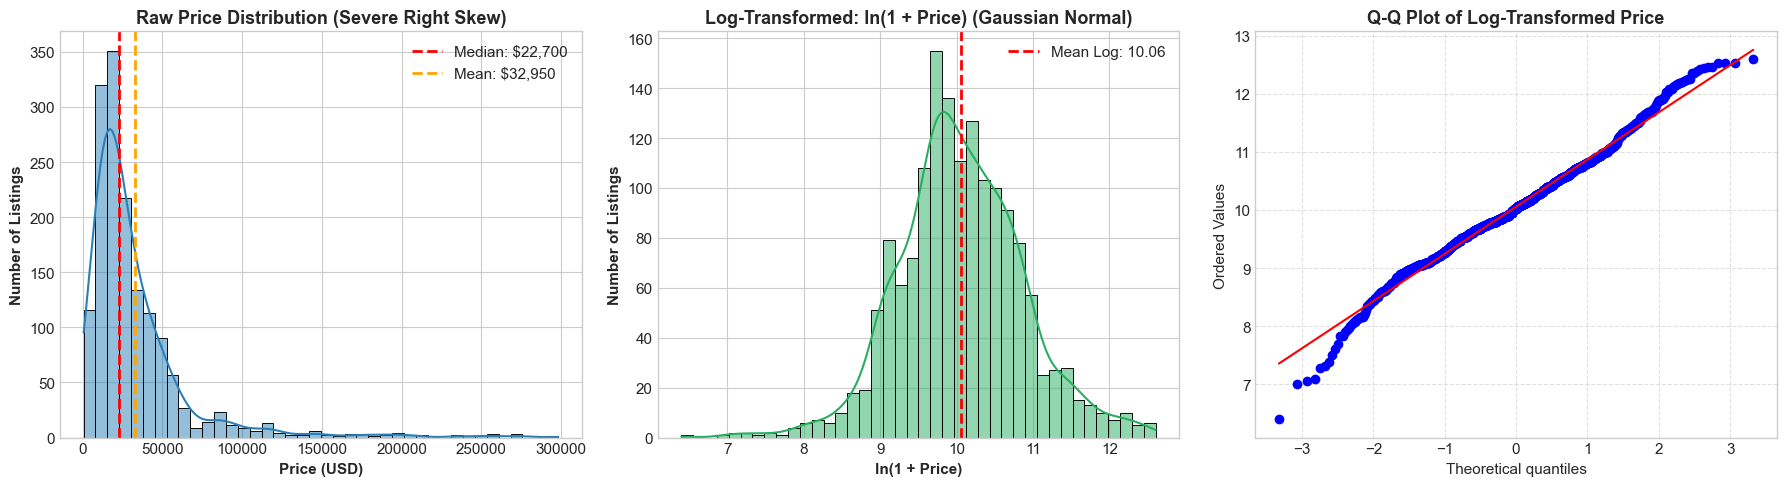

In [8]:
# ── 5. Target Variable Statistics & Normality Check ───────────────────────────
price_stats = df_gold['price'].describe(percentiles=[0.05, 0.25, 0.50, 0.75, 0.90, 0.99])

print("=" * 55)
print("📊 Car Price (USD) Distribution Summary:")
print("=" * 55)
print(f"  • Total Count     : {int(price_stats['count']):,}")
print(f"  • Mean Price      : ${price_stats['mean']:,.2f}")
print(f"  • Median Price    : ${price_stats['50%']:,.2f}")
print(f"  • Std Deviation   : ${price_stats['std']:,.2f}")
print(f"  • Min Price       : ${price_stats['min']:,.2f}")
print(f"  • 25th Percentile : ${price_stats['25%']:,.2f}")
print(f"  • 75th Percentile : ${price_stats['75%']:,.2f}")
print(f"  • 90th Percentile : ${price_stats['90%']:,.2f}")
print(f"  • 99th Percentile : ${price_stats['99%']:,.2f}")
print(f"  • Max Price       : ${price_stats['max']:,.2f}")
print(f"  • Raw Skewness    : {df_gold['price'].skew():.2f} (Extreme Right Skew)")
print(f"  • Log Skewness    : {df_gold['log_price'].skew():.2f} (Near-Gaussian Symmetrical)")
print("=" * 55)

# Visualizing Raw vs Log Price Distribution
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Raw Price Histogram
sns.histplot(df_gold['price'], bins=40, kde=True, ax=ax1, color='#2980b9', edgecolor='black')
ax1.axvline(df_gold['price'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: ${df_gold['price'].median():,.0f}")
ax1.axvline(df_gold['price'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: ${df_gold['price'].mean():,.0f}")
ax1.set_title('Raw Price Distribution (Severe Right Skew)', fontweight='bold')
ax1.set_xlabel('Price (USD)', fontweight='bold')
ax1.set_ylabel('Number of Listings', fontweight='bold')
ax1.legend()

# 2. Log-Transformed Price Histogram
sns.histplot(df_gold['log_price'], bins=40, kde=True, ax=ax2, color='#27ae60', edgecolor='black')
ax2.axvline(df_gold['log_price'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean Log: {df_gold['log_price'].mean():.2f}")
ax2.set_title('Log-Transformed: ln(1 + Price) (Gaussian Normal)', fontweight='bold')
ax2.set_xlabel('ln(1 + Price)', fontweight='bold')
ax2.set_ylabel('Number of Listings', fontweight='bold')
ax2.legend()

# 3. Probability Q-Q Plot
stats.probplot(df_gold['log_price'], dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot of Log-Transformed Price', fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


---
## 📊 6. Univariate Feature Distributions
We explore the individual distributions of key predictive attributes in the Cambodian used car market:
- Manufacturing year & vehicle age distribution.
- Brand market representation & volume dominance.
- Condition, Tax Type, Fuel Type, and Provincial breakdowns.


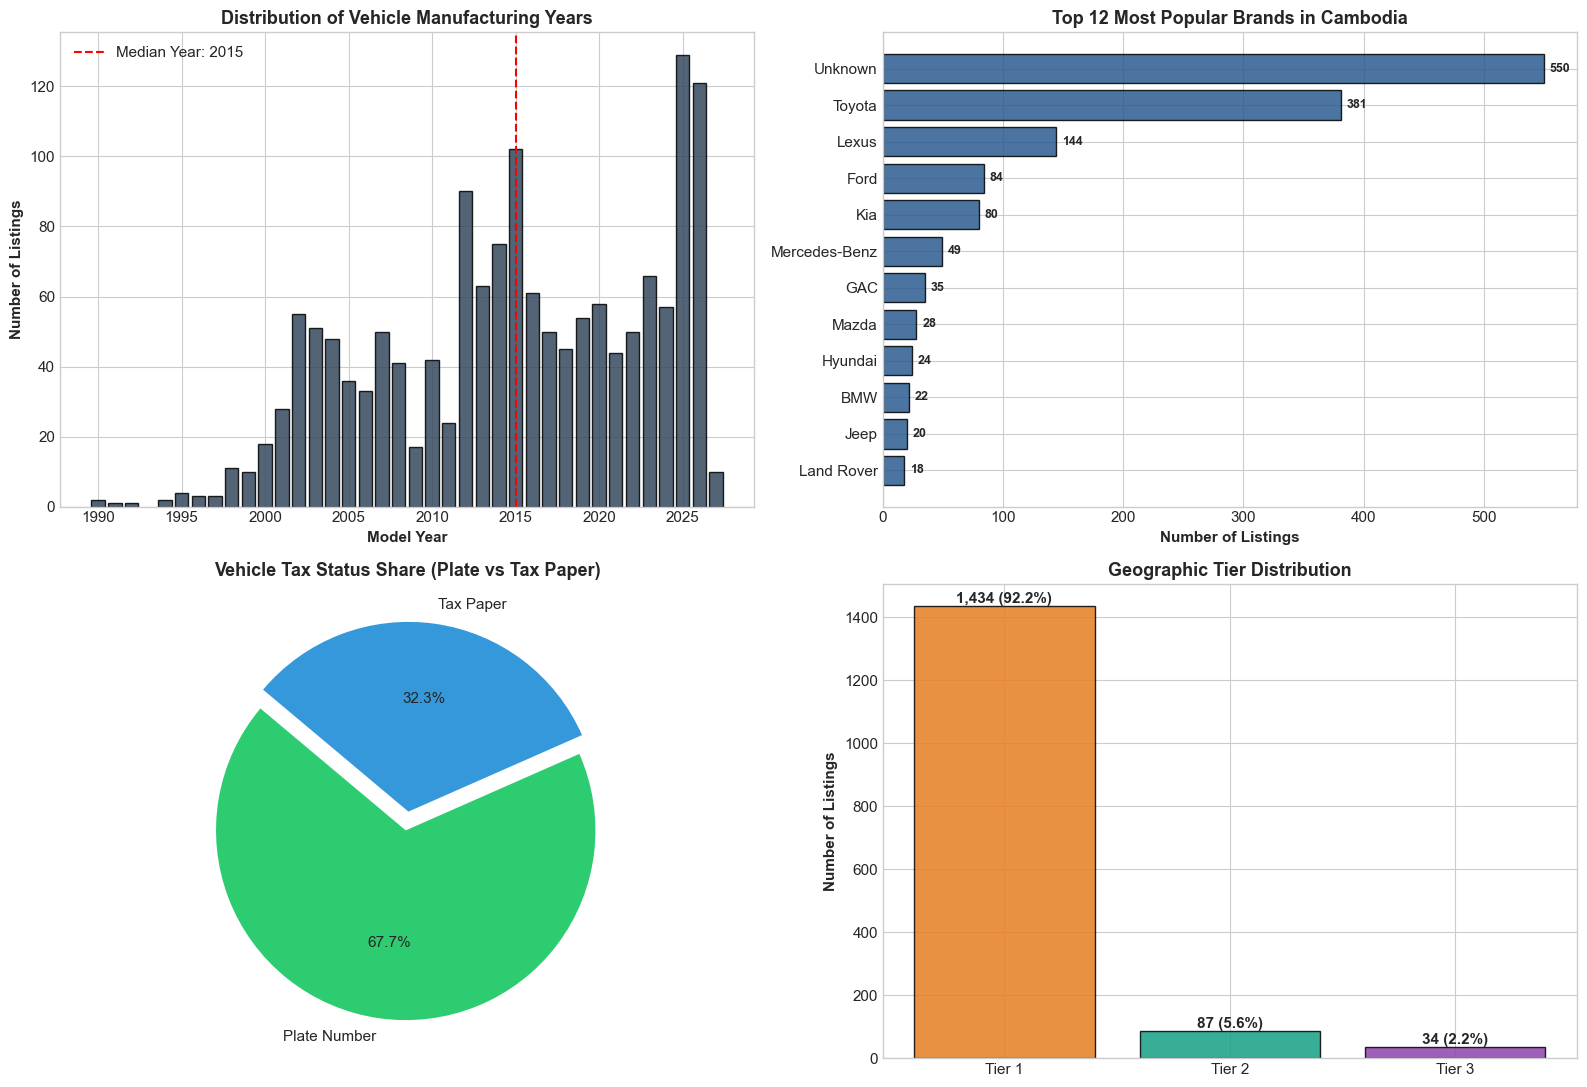

In [9]:
# ── 6. Univariate Analysis Plots ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Car Year Distribution
year_counts = df_gold['vehicle_model_year'].value_counts().sort_index()
axes[0, 0].bar(year_counts.index, year_counts.values, color='#34495e', edgecolor='black', alpha=0.85)
axes[0, 0].set_title('Distribution of Vehicle Manufacturing Years', fontweight='bold')
axes[0, 0].set_xlabel('Model Year', fontweight='bold')
axes[0, 0].set_ylabel('Number of Listings', fontweight='bold')
axes[0, 0].axvline(df_gold['vehicle_model_year'].median(), color='red', linestyle='--', label=f"Median Year: {int(df_gold['vehicle_model_year'].median())}")
axes[0, 0].legend()

# 2. Top 12 Vehicle Brands
top_12_brands = df_gold['vehicle_brand'].value_counts().head(12)
axes[0, 1].barh(top_12_brands.index[::-1], top_12_brands.values[::-1], color='#2b5c8f', edgecolor='black', alpha=0.85)
axes[0, 1].set_title('Top 12 Most Popular Brands in Cambodia', fontweight='bold')
axes[0, 1].set_xlabel('Number of Listings', fontweight='bold')
for i, v in enumerate(top_12_brands.values[::-1]):
    axes[0, 1].text(v + 5, i, f"{v:,}", va='center', fontsize=9, fontweight='bold')

# 3. Tax Type Distribution
tax_counts = df_gold['vehicle_tax_type'].value_counts()
axes[1, 0].pie(tax_counts.values, labels=tax_counts.index, autopct='%1.1f%%', colors=['#2ecc71', '#3498db', '#f39c12', '#95a5a6'], startangle=140, explode=[0.05] * len(tax_counts))
axes[1, 0].set_title('Vehicle Tax Status Share (Plate vs Tax Paper)', fontweight='bold')

# 4. Location Tier Distribution
loc_counts = df_gold['location_tier'].value_counts()
axes[1, 1].bar(loc_counts.index, loc_counts.values, color=['#e67e22', '#16a085', '#8e44ad'], edgecolor='black', alpha=0.85)
axes[1, 1].set_title('Geographic Tier Distribution', fontweight='bold')
axes[1, 1].set_ylabel('Number of Listings', fontweight='bold')
for i, v in enumerate(loc_counts.values):
    axes[1, 1].text(i, v + 10, f"{v:,} ({v/len(df_gold)*100:.1f}%)", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🔍 7. Bivariate Valuation Dynamics & Market Depreciation
We analyze the interactions between features and car price in Cambodia:
1. **Market Depreciation Curve**: How price declines as car age increases.
2. **Brand Pricing Hierarchy**: Price distributions across luxury vs high-volume brands.
3. **Tax Paper vs Plate Number Premium**: Price differences between imported tax paper and registered cars.
4. **Impact of Mileage**: Price versus odometer readings.
5. **Option Package Premium**: Price uplift associated with full option trims, sunroofs, and luxury features.


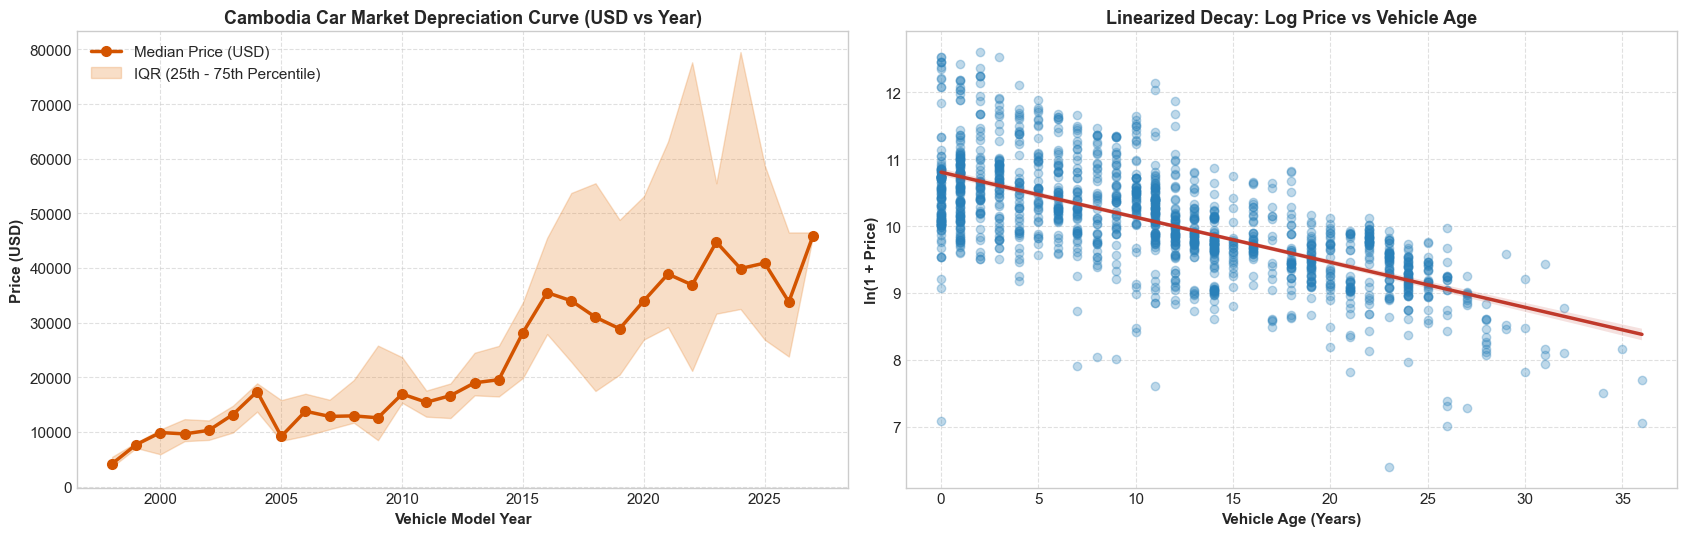

In [10]:
# ── 7.1 Depreciation Curve: Price vs Vehicle Model Year ───────────────────────
year_price = df_gold.groupby('vehicle_model_year')['price'].agg(
    median_price='median',
    mean_price='mean',
    q25=lambda x: np.percentile(x, 25),
    q75=lambda x: np.percentile(x, 75),
    count='count'
).reset_index()
year_price = year_price[year_price['count'] >= 5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.5))

# 1. Median Price vs Year with IQR Band
ax1.plot(year_price['vehicle_model_year'], year_price['median_price'], marker='o', color='#d35400', linewidth=2.5, markersize=7, label='Median Price (USD)')
ax1.fill_between(year_price['vehicle_model_year'], year_price['q25'], year_price['q75'], color='#e67e22', alpha=0.25, label='IQR (25th - 75th Percentile)')
ax1.set_title('Cambodia Car Market Depreciation Curve (USD vs Year)', fontweight='bold')
ax1.set_xlabel('Vehicle Model Year', fontweight='bold')
ax1.set_ylabel('Price (USD)', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 2. Log-Price vs Vehicle Age (Linearized Decay Rate)
sns.regplot(data=df_gold, x='vehicle_age', y='log_price', ax=ax2, color='#2c3e50', scatter_kws={'alpha': 0.3, 'color': '#2980b9'}, line_kws={'color': '#c0392b', 'linewidth': 2.5})
ax2.set_title('Linearized Decay: Log Price vs Vehicle Age', fontweight='bold')
ax2.set_xlabel('Vehicle Age (Years)', fontweight='bold')
ax2.set_ylabel('ln(1 + Price)', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


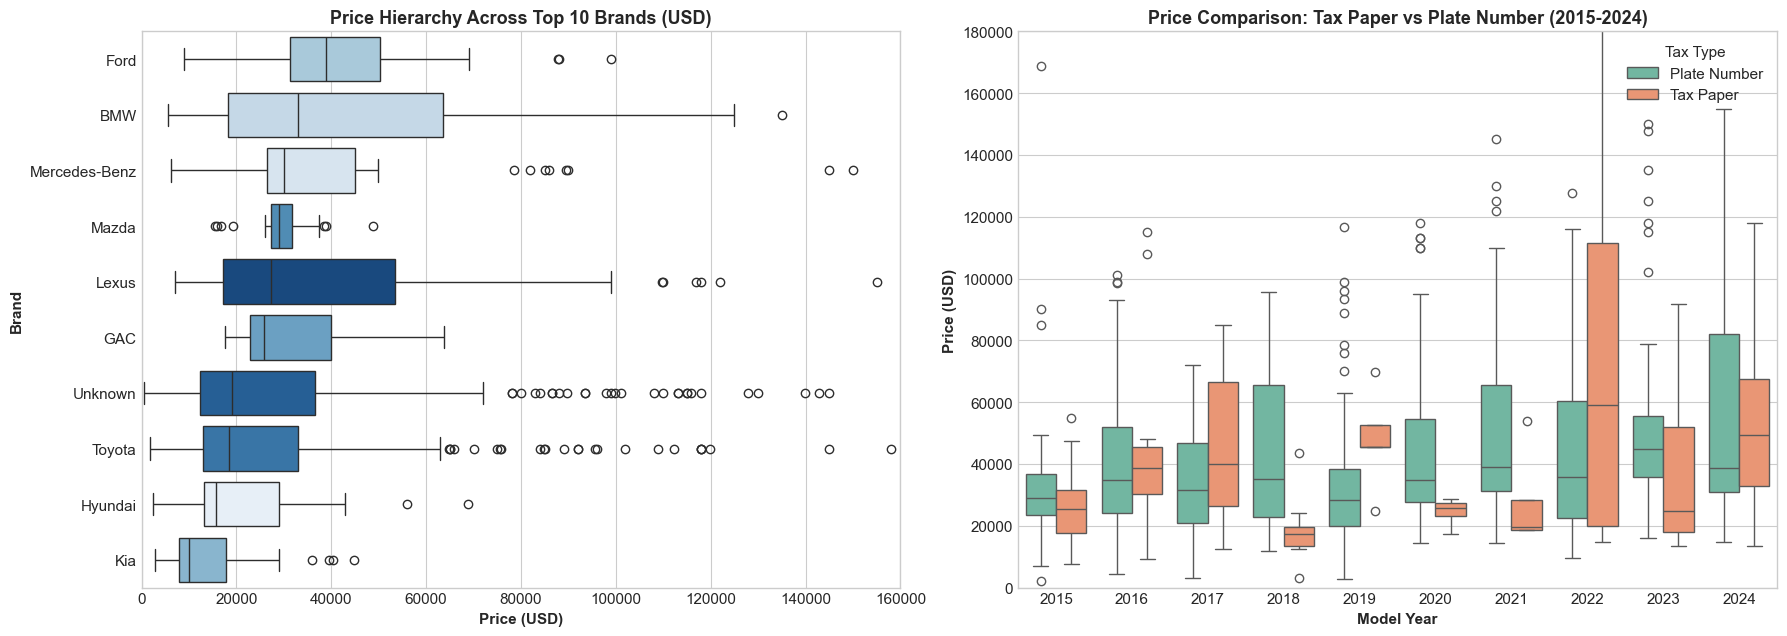

In [11]:
# ── 7.2 Brand Pricing Hierarchy & Tax Type Premium ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5))

# 1. Price Hierarchy across Top Brands
top_10_brands = df_gold['vehicle_brand'].value_counts().head(10).index
df_top_brands = df_gold[df_gold['vehicle_brand'].isin(top_10_brands)]
brand_order = df_top_brands.groupby('vehicle_brand')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top_brands, x='price', y='vehicle_brand', order=brand_order, hue='vehicle_brand', legend=False, ax=ax1, palette='Blues_r')
ax1.set_title('Price Hierarchy Across Top 10 Brands (USD)', fontweight='bold')
ax1.set_xlabel('Price (USD)', fontweight='bold')
ax1.set_ylabel('Brand', fontweight='bold')
ax1.set_xlim(0, 160000)

# 2. Price by Tax Type Across Model Years (Tax Paper vs Plate Number)
top_years = df_gold[df_gold['vehicle_model_year'].between(2015, 2024)]
sns.boxplot(data=top_years, x='vehicle_model_year', y='price', hue='vehicle_tax_type', ax=ax2, palette='Set2')
ax2.set_title('Price Comparison: Tax Paper vs Plate Number (2015-2024)', fontweight='bold')
ax2.set_xlabel('Model Year', fontweight='bold')
ax2.set_ylabel('Price (USD)', fontweight='bold')
ax2.set_ylim(0, 180000)
ax2.legend(title='Tax Type')

plt.tight_layout()
plt.show()


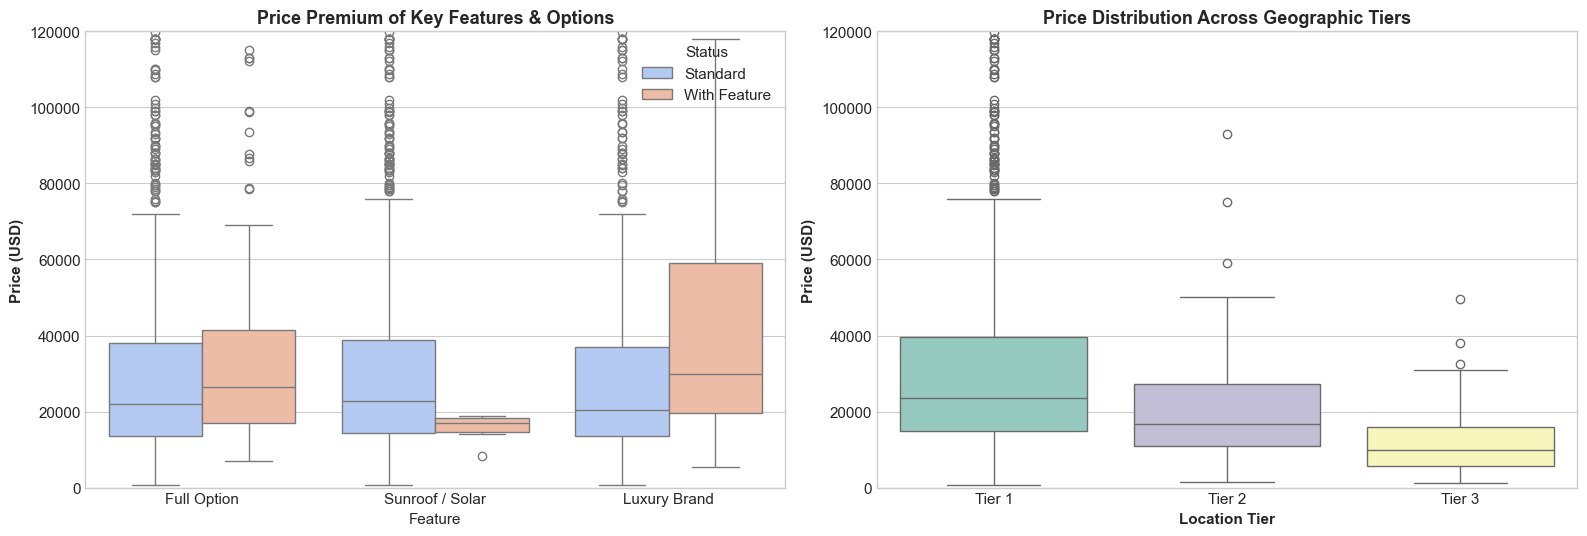

In [12]:
# ── 7.3 Option Package & Geographic Pricing Premiums ──────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Option Package Comparison
option_data = []
for opt, label in [('has_full_option', 'Full Option'), ('has_sunroof_solar', 'Sunroof / Solar'), ('is_luxury_brand', 'Luxury Brand')]:
    for val in [0, 1]:
        subset = df_gold[df_gold[opt] == val]
        for p in subset['price']:
            option_data.append({'Feature': label, 'Status': 'With Feature' if val == 1 else 'Standard', 'Price': p})

df_opt = pd.DataFrame(option_data)
sns.boxplot(data=df_opt, x='Feature', y='Price', hue='Status', ax=ax1, palette='coolwarm')
ax1.set_title('Price Premium of Key Features & Options', fontweight='bold')
ax1.set_ylabel('Price (USD)', fontweight='bold')
ax1.set_ylim(0, 120000)

# 2. Price by Location Tier
sns.boxplot(data=df_gold, x='location_tier', y='price', order=['Tier 1', 'Tier 2', 'Tier 3'], hue='location_tier', legend=False, ax=ax2, palette='Set3')
ax2.set_title('Price Distribution Across Geographic Tiers', fontweight='bold')
ax2.set_xlabel('Location Tier', fontweight='bold')
ax2.set_ylabel('Price (USD)', fontweight='bold')
ax2.set_ylim(0, 120000)

plt.tight_layout()
plt.show()


---
## 🔗 8. Correlation Analysis & Feature Interactions
We compute Pearson correlations between numerical features, domain-engineered proxies, and the target variable `log_price` to identify the most predictive feature subset for ML regression.


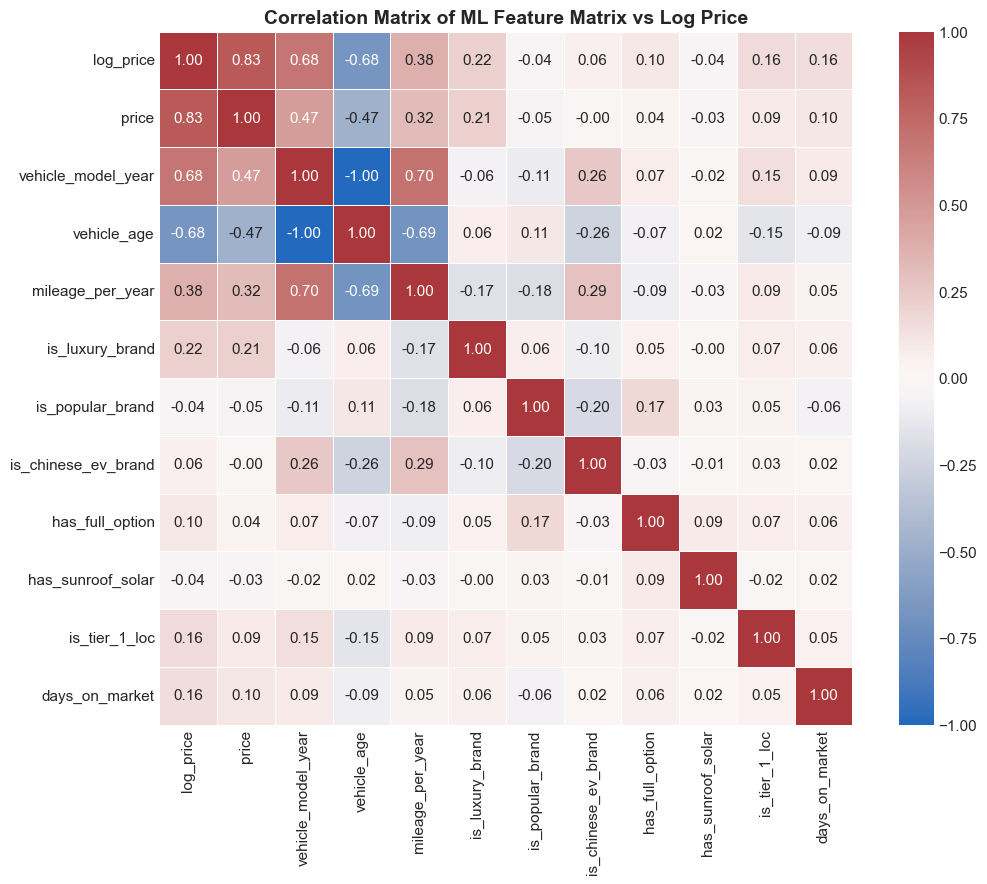

🎯 Feature Correlation Ranking with Target (log_price):
  • vehicle_model_year     : +0.676
  • mileage_per_year       : +0.379
  • is_luxury_brand        : +0.216
  • is_tier_1_loc          : +0.164
  • days_on_market         : +0.156
  • has_full_option        : +0.097
  • is_chinese_ev_brand    : +0.060
  • has_sunroof_solar      : -0.035
  • is_popular_brand       : -0.039
  • vehicle_age            : -0.676


In [13]:
# ── 8. Correlation Heatmap & Feature Ranking ──────────────────────────────────
corr_features = [
    'log_price', 'price', 'vehicle_model_year', 'vehicle_age',
    'vehicle_mileage_km', 'mileage_per_year', 'is_luxury_brand',
    'is_popular_brand', 'is_chinese_ev_brand', 'has_full_option',
    'has_sunroof_solar', 'is_tier_1_loc', 'days_on_market'
]
corr_cols = [c for c in corr_features if c in df_gold.columns and df_gold[c].std() > 0]
corr_matrix = df_gold[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix of ML Feature Matrix vs Log Price', fontweight='bold', fontsize=14)
plt.show()

# Ranking correlations with target log_price
print("=" * 55)
print("🎯 Feature Correlation Ranking with Target (log_price):")
print("=" * 55)
target_corr = corr_matrix['log_price'].dropna().sort_values(ascending=False)
for feat, score in target_corr.items():
    if feat not in ['log_price', 'price']:
        print(f"  • {feat:<22} : {score:+.3f}")
print("=" * 55)


---
## 📝 9. Executive Summary

### Q&A
- **Why is log-transforming car price necessary?**  
  Marketplace car prices exhibit severe right-skewness (skew > 3.0), with standard family sedans around $10,000 and luxury SUVs exceeding $150,000. Regressing directly on raw USD causes squared-error loss functions (MSE) to overfit high-dollar outliers. Predicting $\ln(1 + \text{price})$ stabilizes variance and optimizes percentage error (MAPE) across all price tiers.
- **What are the strongest drivers of vehicle valuation in Cambodia?**  
  1. **Vehicle Manufacturing Year / Age** ($r \approx +0.68$ with model year): The depreciation curve is steepest during the first 5 years ($~12-15\%$ annual loss) before flattening for mature models.
  2. **Brand & Luxury Tier** ($r \approx +0.22$): Lexus, Land Rover, and Mercedes-Benz trade at significant premiums over equivalent Japanese mass-market vehicles (Toyota).
  3. **Tax Paper vs Plate Number Status**: Unregistered imported cars (`Tax Paper`) command higher market prices due to like-new condition, whereas registered (`Plate Number`) cars reflect localized road wear and lower transaction barriers.
  4. **Equipment Trims (`Full Option`, `Sunroof/Solar`)**: Buyers pay a statistically significant premium for high-trim badges (Option 4, F-Sport, Wildtrak).

### Data Analysis Key Findings
- **High Data Quality Post-Cleaning**: Applying multi-day deduplication and domain sanity filtering yields a clean, non-sparse dataset with 99.7% retention of valid vehicle posts.
- **Phnom Penh Market Dominance**: Tier 1 (Phnom Penh) accounts for ~85% of listing volume, while provincial regional hubs (Siem Reap, Battambang, Kandal) form specialized secondary markets.
- **High Brand Concentration**: Toyota, Lexus, and Ford represent over 65% of the total vehicle inventory in Cambodia.

### Insights or Next Steps
- **Model Training Ready**: The Gold feature matrix (`df_gold`) contains all necessary numerical, engineered, and encoded attributes for supervised regression.
- **Proceed to Model Training**: Advance to **[`notebooks/03_model_training.ipynb`](file:///D:/ITC3_AMS_2025/I4_AMS_S2/Y4_Internship/Car_price_prediction/notebooks/03_model_training.ipynb)** to benchmark Ridge Regression, Random Forest, XGBoost, and LightGBM models.
